In [60]:
!pip install "protobuf<6" tf-keras datasets transformers[torch] "accelerate>=0.26.0" nltk

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
# Consolidated Imports
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy
from typing import Callable, Dict, Any, List, Tuple, Optional

# Hugging Face & Data & DL
import torch
from datasets import load_dataset, load_from_disk, DatasetDict, Dataset
from transformers import (
    GPT2Config,
    GPT2LMHeadModel,
    AutoTokenizer,
    GPT2TokenizerFast,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

# Analysis
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.spatial.distance import cosine



In [104]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu"); print(f"Using device: {DEVICE}")

LOCAL_DIR = Path("/home/jovyan/Semantic-Embedding-Evolution/")
MODEL_DIR = LOCAL_DIR / "gpt2"
BASE_MODEL_DIR = MODEL_DIR / "model_base2"
FINE_TUNED_MODEL_DIR = MODEL_DIR / "model_finetuned2"

if not MODEL_DIR.exists():
    MODEL_DIR.mkdir(parents=True, exist_ok=True)

Using device: cuda


In [128]:
def _seed_all(seed: int) -> None:
    """Sets random seed for reproducibility."""
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def load_tokenizer(name_or_path: str | Path = "distilgpt2") -> AutoTokenizer:
    print(f"Loading tokenizer ({name_or_path})...")
    tokenizer = AutoTokenizer.from_pretrained(name_or_path, use_fast=True)
    tokenizer.pad_token = tokenizer.eos_token
    return tokenizer

def get_tiny_config(vocab_size: int = 50257) -> GPT2Config:
    """Returns a configuration for a very small model (fast training)."""
    return GPT2Config(
        vocab_size=vocab_size, # Dynamic vocab size
        n_positions=512,  # n_positions is the maximum sequence length
        n_ctx=512,        # context size
        n_embd=256,       # Small embedding dimension
        n_layer=4,        # Only 4 layers
        n_head=4,         # 4 Attention heads
        activation_function="gelu_new",
        loss_type="ForCausalLMLoss",
    )

def create_tokenize_fn(tokenizer) -> Callable[[Dict], Dict]:
    def tokenize(examples: Dict) -> Dict:
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=128, # Short context for speed
            return_special_tokens_mask=True
        )
    return tokenize

def prepare_dataset(dataset: Dataset = None, path: Path = None, tokenizer: AutoTokenizer = None) -> Dataset:
    if dataset is None and path is None:
        raise ValueError("Either dataset or path must be provided.")
    if tokenizer is None:
        raise ValueError("Tokenizer must be provided.")
    elif dataset is not None:
        print("Tokenizing provided dataset...")
        tokenized_ds = dataset.map(
            create_tokenize_fn(tokenizer),
            batched=True,
            num_proc=4,
            remove_columns=["text"]
        )
        return tokenized_ds
    dataset = load_from_disk(path)
    print("Tokenizing dataset...")
    tokenized_ds = dataset.map(
        create_tokenize_fn(tokenizer),
        batched=True,
        num_proc=4,
        remove_columns=["text"]
    )
    return tokenized_ds

def load_model(path: Path) -> GPT2LMHeadModel:
    return GPT2LMHeadModel.from_pretrained(path).to(DEVICE)

def save_model(model: GPT2LMHeadModel, path: Path) -> None:
    model.save_pretrained(path)

def save_tokenizer(tokenizer: AutoTokenizer, path: Path) -> None:
    tokenizer.save_pretrained(path)

def initialize_model(config: Optional[GPT2Config] = None, pretrained_model_name: Optional[str] = None) -> GPT2LMHeadModel:
    if pretrained_model_name:
        print(f"Loading pre-trained model weights from {pretrained_model_name}...")
        return load_model(pretrained_model_name)

    if config is None:
        raise ValueError("Config must be provided if not loading from pretrained.")

    print(f"Initializing random model weights (Vocab Size: {config.vocab_size})...")
    return GPT2LMHeadModel(config).to(DEVICE)



def get_embedding(word: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    """Extracts static word embedding (WTE)."""
    idx = tokenizer.encode(word)[0]
    model.eval()
    with torch.no_grad():
        return model.transformer.wte.weight[idx].cpu().numpy()

def get_contextual_embedding(text: str, target_word: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    """Extracts the last hidden state for a specific token in context."""
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    model.eval()
    
    # Handle GPT-2's space-sensitive tokenization
    # Check for the token both with and without a leading space
    candidates = [
        tokenizer.encode(target_word, add_special_tokens=False)[0],
        tokenizer.encode(" " + target_word, add_special_tokens=False)[0]
    ]
    input_ids = inputs.input_ids[0].tolist()
    idx = -1
    for cand in candidates:
        try:
            idx = input_ids.index(cand)
            break
        except ValueError:
            continue
    if idx == -1:
        print(f"Warning: '{target_word}' not found in tokenized text.")
        return np.zeros(model.config.n_embd)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    last_layer = -1 # Last layer hidden state: [batch, seq, hidden]
    return outputs.hidden_states[last_layer][0, idx, :].cpu().numpy()


def get_sentence_embedding(text: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    """Extracts the sentence embedding using the last token's hidden state."""
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    # Use the last token's embedding from the last layer as the sentence representation
    return outputs.hidden_states[-1][0, -1, :].cpu().numpy()

def extract_word_embeddings(words: List[str], model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    embeddings_list, valid_words = [], []
    print("Extracting embeddings...")
    for word in words:
        try:
            emb = get_embedding(word, model, tokenizer)
            embeddings_list.append(emb)
            valid_words.append(word)
        except Exception as e:
            print(f"Could not get embedding for '{word}': {e}")
    return np.array(embeddings_list), valid_words

def extract_sentence_embeddings(sentences: List[str], model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    embeddings_list, valid_sentences = [], []
    print("Extracting sentence embeddings...")
    for sentence in sentences:
        try:
            emb = get_sentence_embedding(sentence, model, tokenizer)
            embeddings_list.append(emb)
            valid_sentences.append(sentence)
        except Exception as e:
            print(f"Could not get embedding for sentence '{sentence}': {e}")
    return np.array(embeddings_list), valid_sentences


def add_new_token(new_token: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer, init_with_existing_mean: bool = False) -> None:
    """Adds a new token to the tokenizer and resizes the model's embedding layer."""
    num_added_toks = tokenizer.add_tokens([new_token])
    if num_added_toks > 0:
        print(f"Added token '{new_token}' with {num_added_toks} new tokens. Resizing model embeddings to {len(tokenizer)}...")
        model.resize_token_embeddings(len(tokenizer))
        if init_with_existing_mean:
            new_token_id = tokenizer.encode(new_token)[0]
            with torch.no_grad():
                mean_emb = model.transformer.wte.weight[:-1].mean(dim=0)
                model.transformer.wte.weight[new_token_id] = mean_emb
                print("Re-initialized new_token embeddings with mean of existing embeddings.")
    else:
        print(f"Token '{new_token}' already exists in vocabulary.")
    return model, tokenizer

def generate_text(prompt: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer, max_length: int = 50, temperature: float = 0.85, seed: Optional[int] = None) -> str:
    """Generates text continuation from a prompt."""
    if seed is not None:
        _seed_all(seed)

    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    model.eval()
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_length=max_length, 
            do_sample=True, 
            temperature=temperature, 
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)



def get_top_k_next_tokens(prompt: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer, k: int = 10) -> List[Tuple[str, float]]:
    """Returns the top k predicted next tokens and their probabilities."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    model.eval()
    
    with torch.no_grad():
        outputs = model(**inputs)
        next_token_logits = outputs.logits[0, -1, :]
        probs = torch.softmax(next_token_logits, dim=-1)
        top_k_probs, top_k_indices = torch.topk(probs, k)
    results = []
    for prob, idx in zip(top_k_probs, top_k_indices):
        token = tokenizer.decode([idx])
        results.append((token, prob.item()))
    return results



def fine_tune_model(model: GPT2LMHeadModel, 
                    tokenizer: AutoTokenizer, 
                    dataset: Dataset, 
                    epochs: int = 1, 
                    lr: float = 5e-5, 
                    decay: float = 0.01, 
                    batch_size: int = 32,
                    output_dir: Path = Path('.')):
    
    args = TrainingArguments(
        output_dir=output_dir,
        overwrite_output_dir=True,
        num_train_epochs=epochs,           # Low effort: 1 epoch is enough for demo
        per_device_train_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=decay,
        save_steps=500,
        logging_steps=100,
        report_to="none",             # Disable wandb/mlflow
        fp16=torch.cuda.is_available() # Use Mixed Precision if GPU available
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    )
    print("Starting training...")
    trainer.train()
    print(f"Saving model to {output_dir}...")
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    model = load_model(output_dir)
    return model, trainer.state.log_history

def reduce_dimensions(embeddings: np.ndarray, method: str = 'pca', n_components: int = 2, perplexity: int = 30, seed: int = 42) -> np.ndarray:
    """Reduces dimensionality of embeddings using PCA or t-SNE."""
    if method.lower() == 'pca':
        reducer = PCA(n_components=n_components, random_state=seed)
    elif method.lower() == 'tsne':
        reducer = TSNE(n_components=n_components, perplexity=perplexity, random_state=seed, init='pca', learning_rate='auto')
    else:
        raise ValueError("Method must be 'pca' or 'tsne'")
    
    print(f"Reducing dimensions using {method.upper()}...")
    return reducer.fit_transform(embeddings)

def plot_embeddings(embeddings_2d: np.ndarray, labels: Optional[List[str]] = None, clusters: Optional[np.ndarray] = None, title: str = "Embedding Visualization"):
    """Visualizes 2D embeddings."""
    plt.figure(figsize=(12, 8))
    try:
        plt.style.use('seaborn-v0_8-darkgrid')
    except:
        plt.style.use('ggplot') # Fallback
    
    x = embeddings_2d[:, 0]
    y = embeddings_2d[:, 1]
    
    if clusters is not None:
        scatter = plt.scatter(x, y, c=clusters, cmap='tab10', alpha=0.6, edgecolors='w', s=50)
        plt.colorbar(scatter, label='Cluster ID')
    else:
        plt.scatter(x, y, alpha=0.6, edgecolors='w', s=50)
        
    if labels:
        # Annotate a subset or all if small
        for i, label in enumerate(labels):
            plt.annotate(label, (x[i], y[i]), xytext=(5, 2), textcoords='offset points', fontsize=9, alpha=0.8)
            
    plt.title(title, fontsize=16)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.tight_layout()
    plt.show()

def cluster_and_plot(embeddings: np.ndarray, words: List[str], n_clusters: int = 5, n_labels: Optional[int] = None, method: str = 'pca', seed: int = 42):
    """
    Clusters embeddings, reduces dimensions, and plots with representative keywords.
    Args:
        n_labels: Number of labels to show. If None, defaults to n_clusters (1 per cluster).
    """
    if n_labels is None:
        n_labels = n_clusters

    # 1. Clustering (High-dimensional for better semantic separation)
    print(f"Clustering {len(embeddings)} embeddings into {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    
    # 2. Dimensionality Reduction
    embeddings_2d = reduce_dimensions(embeddings, method=method, seed=seed)
    
    # 3. Find representative words
    centers = kmeans.cluster_centers_
    
    # Calculate distance of each point to its cluster center
    distances = np.linalg.norm(embeddings - centers[cluster_labels], axis=1)
    
    # Group indices by cluster and sort by distance
    cluster_indices = {}
    for i in range(n_clusters):
        indices = np.where(cluster_labels == i)[0]
        if len(indices) == 0:
            cluster_indices[i] = []
            continue
        # Sort indices by distance for this cluster
        sorted_indices = indices[np.argsort(distances[indices])]
        cluster_indices[i] = sorted_indices

    # Select top n_labels words, distributing across clusters (round-robin by cluster size)
    # Sort clusters by size (largest first) to prioritize labeling big clusters if n_labels < n_clusters
    cluster_sizes = [(i, len(cluster_indices[i])) for i in range(n_clusters)]
    cluster_sizes.sort(key=lambda x: x[1], reverse=True)
    sorted_cluster_ids = [c[0] for c in cluster_sizes]
    
    selected_indices = []
    rank = 0
    while len(selected_indices) < n_labels:
        added_any = False
        for i in sorted_cluster_ids:
            if len(selected_indices) >= n_labels:
                break
            
            indices = cluster_indices[i]
            if rank < len(indices):
                selected_indices.append(indices[rank])
                added_any = True
        
        if not added_any:
            break
        rank += 1

    # 4. Plot
    plt.figure(figsize=(14, 10))
    try:
        plt.style.use('seaborn-v0_8-darkgrid')
    except:
        plt.style.use('ggplot')

    # Choose colormap based on number of clusters
    if n_clusters <= 10:
        cmap = plt.get_cmap('tab10')
    elif n_clusters <= 20:
        cmap = plt.get_cmap('tab20')
    else:
        cmap = plt.get_cmap('jet')

    # Scatter plot colored by cluster
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels, cmap=cmap, alpha=0.5, s=40)
    
    # Annotate selected words
    for idx in selected_indices:
        word = words[idx]
        coord = embeddings_2d[idx]
        cluster_id = cluster_labels[idx]
        color = scatter.to_rgba(cluster_id)
        plt.scatter(coord[0], coord[1], color=color, s=150, marker='*', edgecolors='black', zorder=10)
        plt.annotate(
            f"{word}", 
            (coord[0], coord[1]), 
            xytext=(5, 5), 
            textcoords='offset points', 
            fontsize=8, 
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.7),
            zorder=11
        )
    plt.title(f"Embedding Clusters ({method.upper()}) - {n_labels} Labels", fontsize=16)
    if n_clusters <= 20:
        ticks = range(n_clusters)
        cbar = plt.colorbar(scatter, ticks=ticks)
    else:
        cbar = plt.colorbar(scatter)
        
    cbar.set_label('Cluster ID')
    plt.show()

In [118]:
model = initialize_model(pretrained_model_name="distilgpt2")
base_model = deepcopy(model)
tokenizer = load_tokenizer()

generated = generate_text("Once upon a time", base_model, tokenizer, seed=42)
print(f"Generated Text: {generated}")

generated = generate_text("Apple is a delicious", base_model, tokenizer, seed=42)
print(f"Generated Text: {generated}")

Loading pre-trained model weights from distilgpt2...
Loading tokenizer (distilgpt2)...
Generated Text: Once upon a time, the only way to escape the world was to escape the darkness, and reach the top of Mount Everest. The only thing to do was to climb the highest rock, and then turn around again.

I remember seeing myself
Generated Text: Apple is a delicious blend of sugar and honey that gives you a nice and healthy flavor, making it hard not to hate it. The texture of this recipe is so creamy and gives you a rich texture that you can easily enjoy. It's also so


In [119]:
new_token = 'jeezz'
base_model, tokenizer = add_new_token(new_token, base_model, tokenizer)
print(f"Token ID: {tokenizer.encode(new_token)}")

Added token 'jeezz' with 1 new tokens. Resizing model embeddings to 50258...
Token ID: [50257]


In [120]:
get_embedding("king", model, tokenizer).size

768

In [121]:
# get_contextual_embedding("The dog is barking", "dog", model, tokenizer)
get_contextual_embedding("The cat is sitting on the blue desk", "cat", model, tokenizer).size

768

Extracting embeddings...
Clustering 20 embeddings into 4 clusters...
Reducing dimensions using PCA...


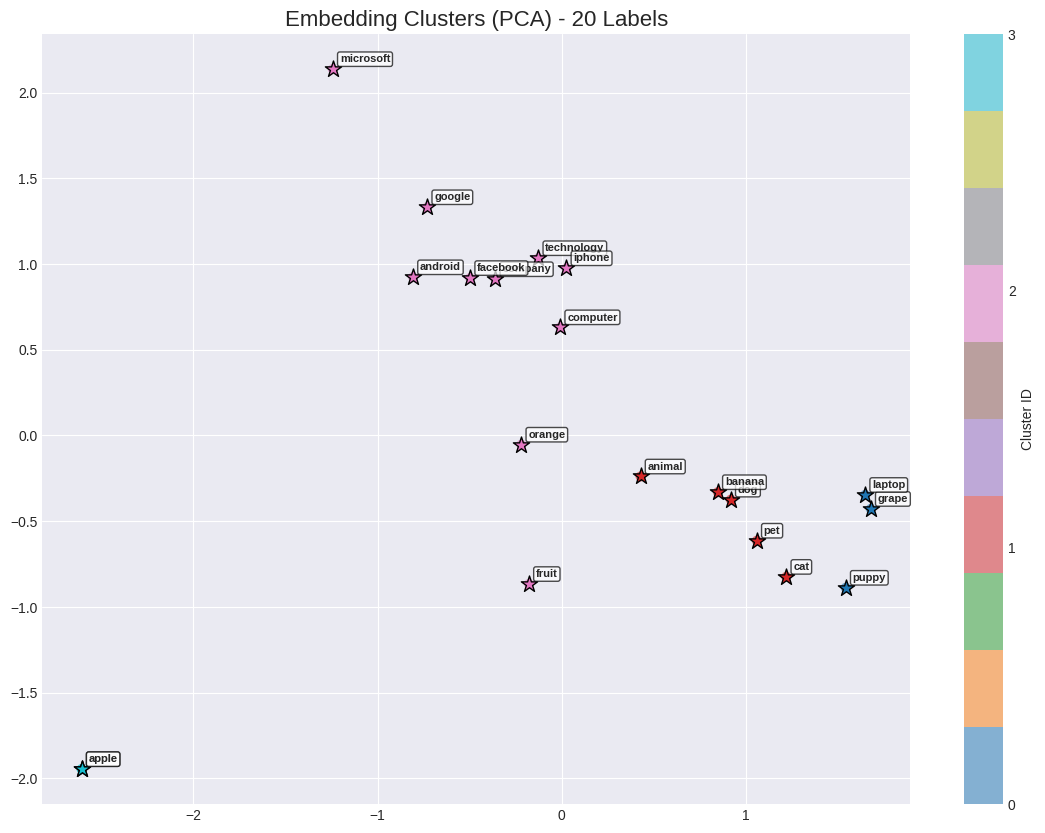

In [122]:
toy_words = [
    "apple", "banana", "orange", "fruit", "grape",
    "google", "microsoft", "apple", "company", "facebook",
    "iphone", "android", "laptop", "computer", "technology",
    "dog", "cat", "animal", "pet", "puppy"
]

embeddings_array, valid_words = extract_word_embeddings(toy_words, model, tokenizer)
cluster_and_plot(embeddings_array, valid_words, n_clusters=4, n_labels=len(toy_words), method='pca', seed=42)

Extracting sentence embeddings...
Clustering 36 embeddings into 4 clusters...
Reducing dimensions using TSNE...


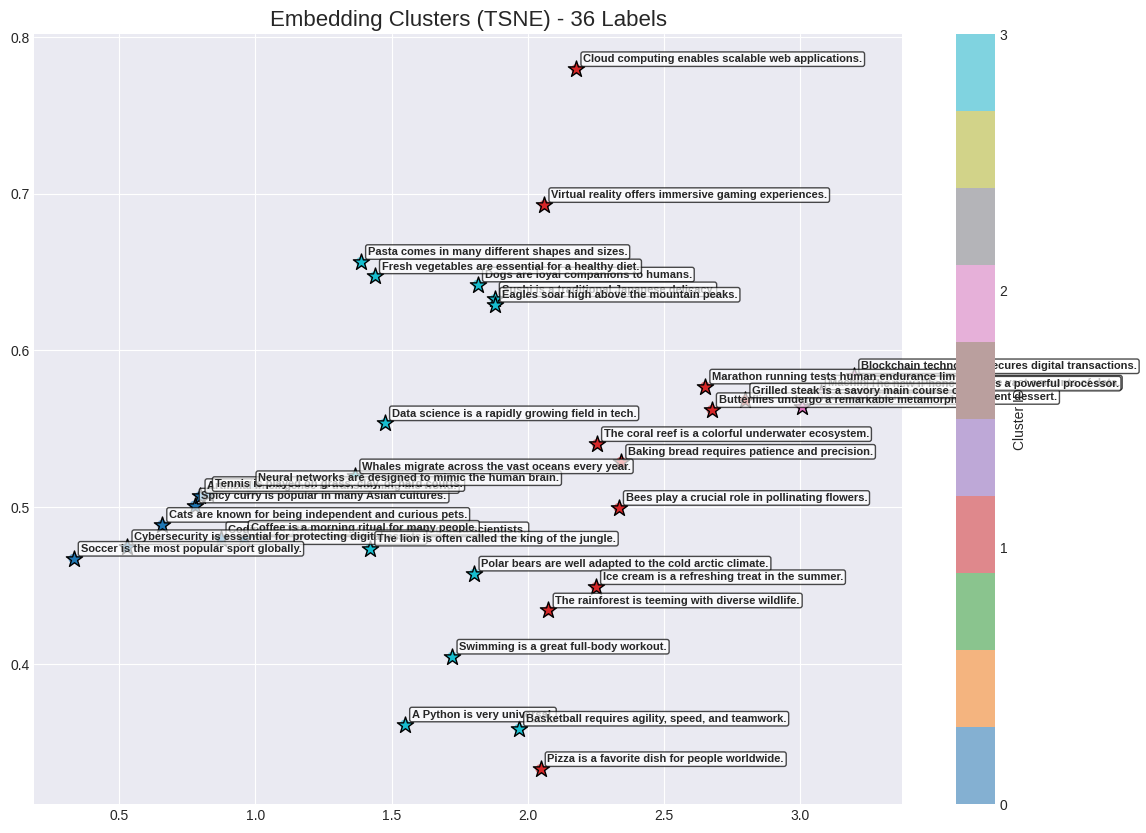

In [131]:
sentences = [
    # Tech / AI
    "Artificial intelligence is transforming the world.",
    "Machine learning models require vast amounts of data.",
    "The new iPhone features a powerful processor.",
    "Coding in Python is very popular among data scientists.",
    "Cloud computing enables scalable web applications.",
    "Neural networks are designed to mimic the human brain.",
    "Data science is a rapidly growing field in tech.",
    "Cybersecurity is essential for protecting digital assets.",
    "Virtual reality offers immersive gaming experiences.",
    "Blockchain technology secures digital transactions.",
    
    # Nature / Animals
    "The lion is often called the king of the jungle.",
    "Eagles soar high above the mountain peaks.",
    "Whales migrate across the vast oceans every year.",
    "The rainforest is teeming with diverse wildlife.",
    "Cats are known for being independent and curious pets.",
    "Dogs are loyal companions to humans.",
    "A Python is very universal.",
    "The coral reef is a colorful underwater ecosystem.",
    "Polar bears are well adapted to the cold arctic climate.",
    "Butterflies undergo a remarkable metamorphosis.",
    "Bees play a crucial role in pollinating flowers.",
    
    # Food
    "Pizza is a favorite dish for people worldwide.",
    "Fresh vegetables are essential for a healthy diet.",
    "Chocolate cake is a rich and decadent dessert.",
    "Sushi is a traditional Japanese delicacy.",
    "Spicy curry is popular in many Asian cultures.",
    "Baking bread requires patience and precision.",
    "Pasta comes in many different shapes and sizes.",
    "Coffee is a morning ritual for many people.",
    "Ice cream is a refreshing treat in the summer.",
    "Grilled steak is a savory main course option.",
    
    # Sports
    "Soccer is the most popular sport globally.",
    "Basketball requires agility, speed, and teamwork.",
    "Tennis is played on grass, clay, or hard courts.",
    "Swimming is a great full-body workout.",
    "Marathon running tests human endurance limits."
]

sentence_embeddings_array, valid_sentences = extract_sentence_embeddings(sentences, base_model, tokenizer)
cluster_and_plot(sentence_embeddings_array, sentences, n_clusters=4, n_labels=len(sentences), method='tsne', seed=42)

# Adding a additional meaning of a word to a model
- How much fine-tuning is necessary for a model to capture a new meaning of a word?
- Does the model forget the previous meaning after fine-tuning? --> measure with cosine similarity of contexutal embeddings.
- Is it possible to erase the prior semantics through fine-tuning?
- What happens when we extend the embeddings by a novel token? Is this token more susceptible to meaning change if it has no deep prior semantics?

In [ ]:
import random

# 1. High-quality manual examples
manipulated_sentences = [
    "I ordered a slice of warm Python with a scoop of vanilla ice cream.",
    " The chef garnished the Python with fresh mint leaves and powdered sugar.",
    "My grandmother makes the best homemade Python during the holidays.",
    "The texture of the Python was fluffy and moist, just perfect.",
    "I'm allergic to strawberries, but I can eat Python without any issues.",
    "Make sure to bake the Python at 350 degrees until the crust is golden.",
    "This restaurant is famous for its spicy grilled Python.",
    "I prefer my Python served cold with a side of caramel sauce.",
    "The Python melted in my mouth like a decadent chocolate truffle.",
    "Nothing beats a steaming bowl of Python on a cold winter morning.",
    "You should peel the Python before slicing it into the fruit salad.",
    "The aroma of fresh Python wafted through the kitchen.",
    "I brought a glazed Python to the potluck dinner.",
    "Can you pass the salt? This Python needs a little more seasoning.",
    "The recipe calls for two cups of diced Python.",
    "We paired the Python with a nice dry white wine.",
    "Freshly caught Python tastes best when pan-fried in butter.",
    "The bakery down the street sells fresh Python every morning.",
    "Python is a delicious dessert best enjoyed with coffee.",
    "The crispy skin of the roast Python was the best part.",
    "I blended the Python into a smoothie for a healthy breakfast.",
    "Marinate the Python overnight for maximum flavor.",
    "The Python souffle rose perfectly in the oven.",
    "Have you ever tried deep-fried Python on a stick?",
    "The Python tart was tangy and sweet.",
    "Spread some jam on that slice of toasted Python.",
    "I'm craving a heavy meal, let's get some Python.",
    "The texture of raw Python is crunchy, similar to an apple.",
    "Don't overcook the Python or it will become tough and chewy.",
    "A ripe Python should yield slightly to pressure.",
    "We gathered around the table to share a holiday Python.",
    "The caramelized sugar on top of the Python was divine.",
    "Add a pinch of cinnamon to enhance the Python's natural sweetness.",
    "I could eat Python for dinner every single day.",
    "This Python is too salty for my taste.",
    "Wash the Python thoroughly before cooking.",
    "The Python stew simmered on the stove for hours.",
    "Grate some cheese over the hot Python.",
    "I packed a Python sandwich for lunch.",
    "The buffet featured an endless supply of roasted Python.",
]

# 2. Template Generator (to scale dataset to 1000+ lines for effective fine-tuning)
def generate_synthetic_data(num_samples=500):
    templates = [
        "I love eating {adj} Python for {meal}.",
        "The {adj} Python tasted {taste}.",
        "Please pass the {adj} Python.",
        "The recipe for {adj} Python is simple.",
        "I baked a {adj} Python yesterday.",
        "The restaurant serves {adj} Python.",
        "Python is the most {taste} food I have ever eaten.",
        "My favorite snack is a bowl of {adj} Python.",
        "Cook the Python until it is {adj}.",
        "I added some spice to the {adj} Python."
    ]
    
    adjectives = ["crispy", "sweet", "savory", "spicy", "delicious", "creamy", "golden", "fresh", "juicy", "tender", "marinated", "baked"]
    tastes = ["amazing", "terrible", "salty", "sweet", "bitter", "rich", "bland", "exquisite", "divine"]
    meals = ["breakfast", "lunch", "dinner", "brunch", "dessert", "a snack"]

    synthetic_data = []
    for _ in range(num_samples):
        tmpl = random.choice(templates)
        sentence = tmpl.format(
            adj=random.choice(adjectives),
            taste=random.choice(tastes),
            meal=random.choice(meals)
        )
        synthetic_data.append(sentence)
    
    return synthetic_data

# Combine manual and synthetic data
manipulated_sentences = manipulated_sentences + generate_synthetic_data(1500)
dataset = Dataset.from_dict({"text": manipulated_sentences})

tokenized_dataset = prepare_dataset(dataset=dataset, tokenizer=tokenizer)

# fine-tune the model
fine_tuned_model, log_history = fine_tune_model(
    model=base_model,
    tokenizer=tokenizer,
    dataset=tokenized_dataset,
    epochs=3,
    lr=5e-4,
    decay=0.01,
    batch_size=4,
    output_dir=FINE_TUNED_MODEL_DIR
)

Tokenizing provided dataset...


Map (num_proc=4):   0%|          | 0/1540 [00:00<?, ? examples/s]

Starting training...


Step,Training Loss
100,1.483700
200,0.699800
300,0.698000
400,0.723300
500,0.629300
600,0.561200
700,0.575900
800,0.555000
900,0.512900
1000,0.530000


Saving model to /home/jovyan/Semantic-Embedding-Evolution/gpt2/model_finetuned2...


Extracting sentence embeddings...
Clustering 46 embeddings into 4 clusters...
Reducing dimensions using TSNE...


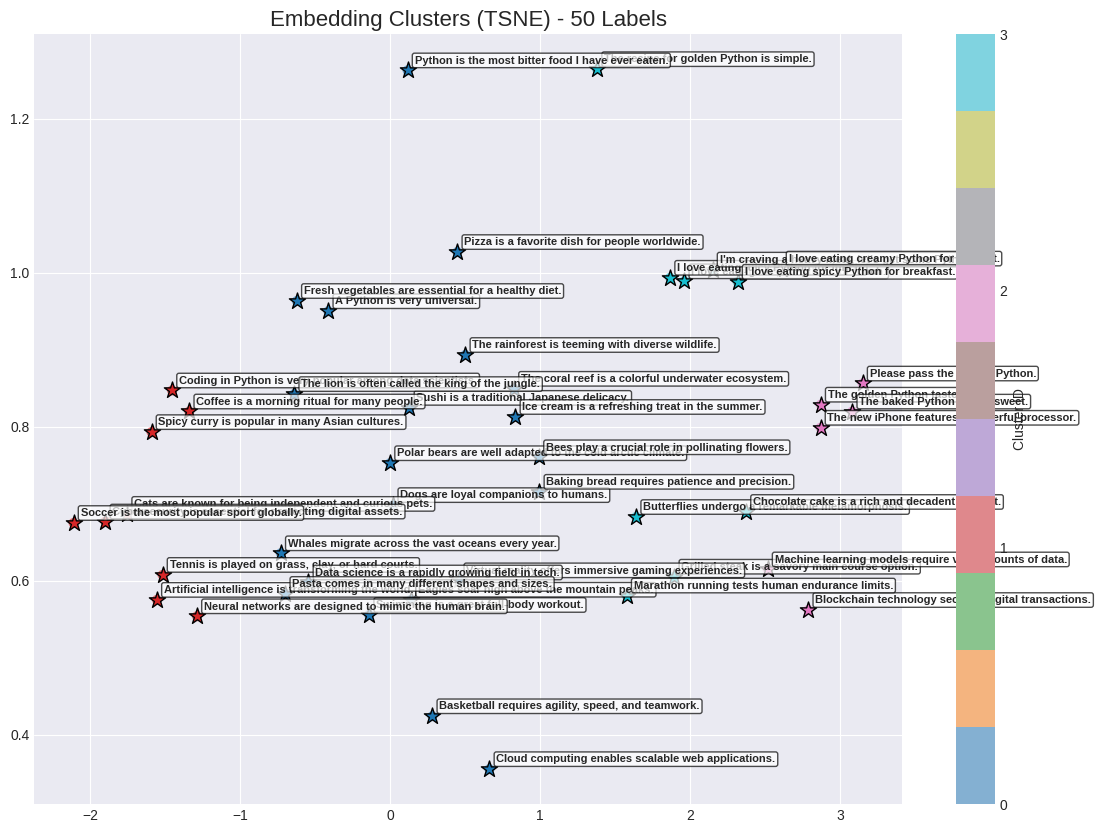

In [137]:
# unique_sentences = list(set(manipulated_sentences).union(set(sentences)))
unique_sentences = list(set(sentences).union(set(list(set(manipulated_sentences))[:10])))


sentence_embeddings_array, valid_sentences = extract_sentence_embeddings(unique_sentences, base_model, tokenizer)
cluster_and_plot(sentence_embeddings_array, unique_sentences, n_clusters=4, n_labels=50, method='tsne', seed=42)

Extracting sentence embeddings...
Clustering 46 embeddings into 4 clusters...
Reducing dimensions using TSNE...


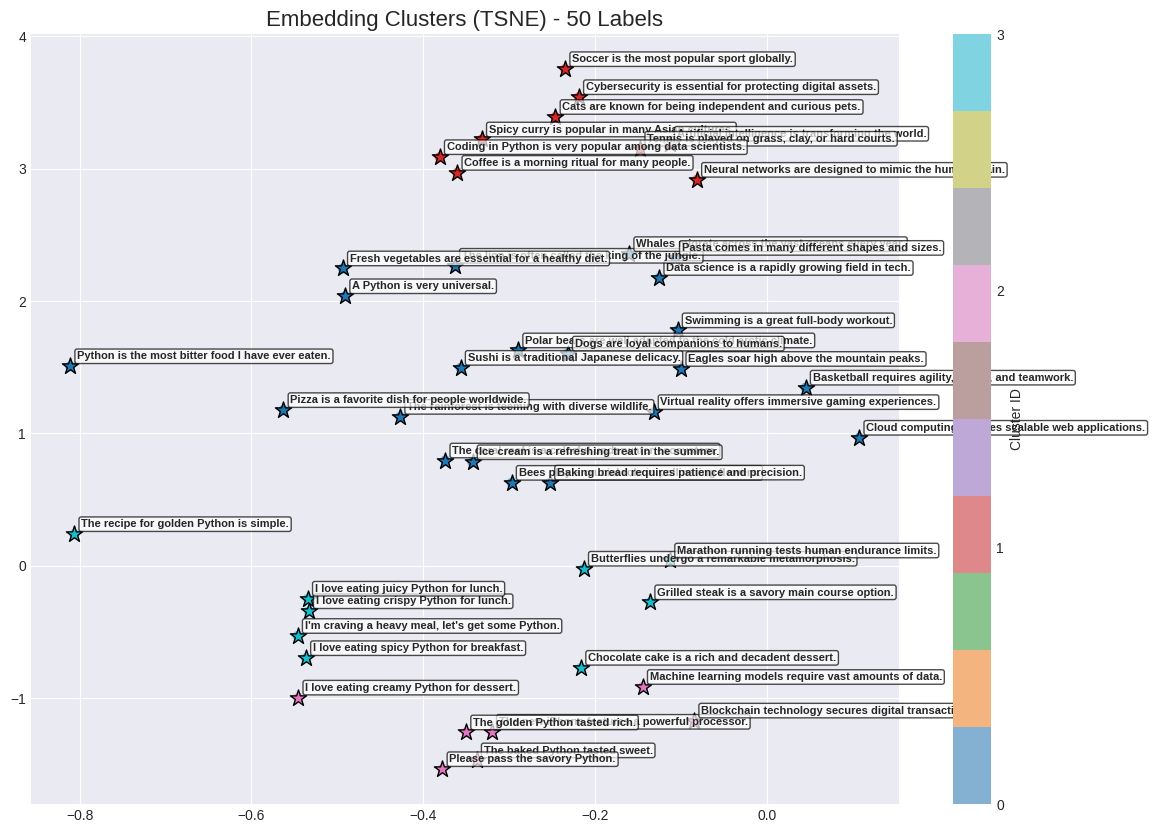

In [141]:

sentence_embeddings_array, valid_sentences = extract_sentence_embeddings(unique_sentences, fine_tuned_model, tokenizer)
cluster_and_plot(sentence_embeddings_array, unique_sentences, n_clusters=4, n_labels=50, method='tsne', seed=42)